In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import precision_score, recall_score, f1_score
from scipy.sparse import hstack

## Data Preprocessing:

In [3]:
# Load dataset
df = pd.read_csv("anime.csv")
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [10]:
df[["rating", "members"]].describe().T

,count,mean,std,min,25%,50%,75%,max
rating,12017.0,6.478264,1.023857,1.67,5.89,6.57,7.18,10.0
members,12017.0,18348.879005,55372.496436,12.00,225.00,1552.00,9588.00,1013917.0


In [5]:
df.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [6]:
df = df.dropna(subset=["genre", "rating"])
df.reset_index(drop=True, inplace=True)
df.isnull().sum()

anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64

In [7]:
# Convert episodes to numeric
df["episodes"] = pd.to_numeric(df["episodes"], errors="coerce")
# Fill missing episodes with median
df["episodes"] = df["episodes"].fillna(df["episodes"].median())
df["episodes"].head()

0     1.0
1    64.0
2    51.0
3    24.0
4    51.0
Name: episodes, dtype: float64

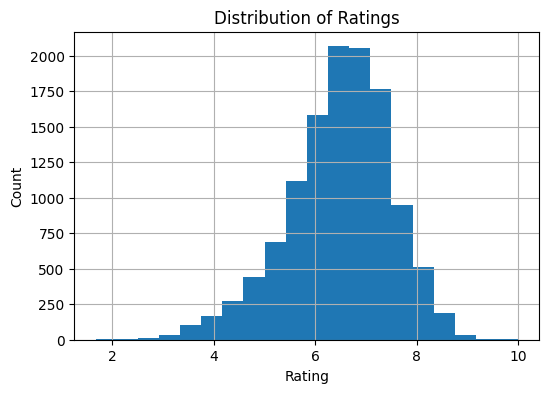

In [11]:
df["rating"].hist(bins=20, figsize=(6,4))
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

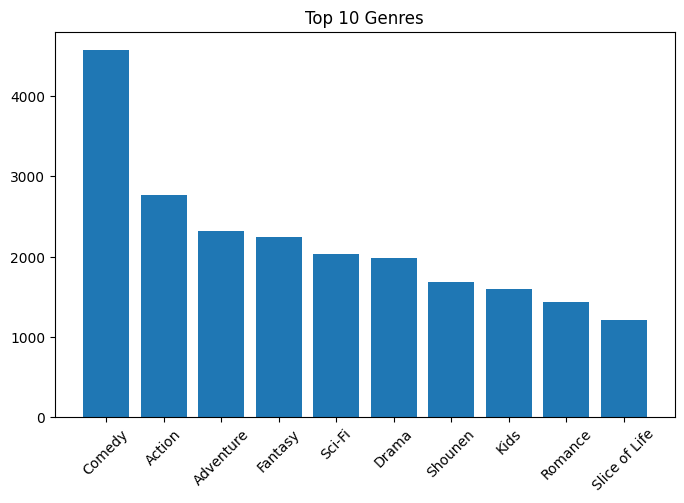

In [12]:
from collections import Counter
import itertools

all_genres = list(itertools.chain.from_iterable(df["genre"].apply(lambda x: x.split(", "))))
genre_counts = Counter(all_genres).most_common(10)
genres, counts = zip(*genre_counts)

plt.figure(figsize=(8,5))
plt.bar(genres, counts)
plt.xticks(rotation=45)
plt.title("Top 10 Genres")
plt.show()

## Feature Extraction: 

In [13]:
# TF-IDF for genre
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import csr_matrix, hstack

tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(df["genre"])

# Scale numerical features
scaler = MinMaxScaler()
num_features = scaler.fit_transform(df[["rating", "members"]])

# Convert numeric features to sparse matrix
num_features_sparse = csr_matrix(num_features)

# Combine genre + rating + members
features = hstack([tfidf_matrix, num_features_sparse])

print("Final feature matrix shape:", features.shape)

Final feature matrix shape: (12017, 48)


- The cosine similarity matrix compares every anime with every other anime.
- Each value represents how similar two anime are.
- The closer the value is to 1, the more similar they are.
- The closer to 0, the less similar they are.

In [14]:
# 6. Cosine Similarity
cosine_sim = cosine_similarity(features, features)
print("Cosine similarity matrix shape:", cosine_sim.shape)

Cosine similarity matrix shape: (12017, 12017)


- The cosine similarity matrix compares each anime with all other anime in the dataset.
- A value close to 1 means the two anime are very similar, while a value close to 0 means they are not similar.

## Recommendation System:

In [15]:
# Map anime name to index
indices = pd.Series(df.index, index=df["name"]).drop_duplicates()

def recommend(anime_name, top_n=5, threshold=0.3):
    if anime_name not in indices:
        return f"'{anime_name}' not found"
    idx = indices[anime_name]
    # Get similarity scores
    sim_scores = list(enumerate(cosine_sim[idx]))
    # Filter by threshold and remove itself
    sim_scores = [(i, score) for i, score in sim_scores if score >= threshold and i != idx]
    # Sort by similarity score
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    # Get top N indices
    sim_indices = [i for i, _ in sim_scores[:top_n]]
    return df.iloc[sim_indices][["name", "genre", "type", "rating"]]

In [18]:
test_titles = ["Steins;Gate","Fullmetal Alchemist: Brotherhood","Kimi no Na wa."]

for title in test_titles:
    print(f"\nRecommendations for {title}:")
    display(recommend(title))


Recommendations for Steins;Gate:


,name,genre,type,rating
59,Steins;Gate Movie: Fuka Ryouiki no Déjà vu,"Sci-Fi, Thriller",Movie,8.61
126,Steins;Gate: Oukoubakko no Poriomania,"Sci-Fi, Thriller",Special,8.46
196,Steins;Gate: Kyoukaimenjou no Missing Link - D...,"Sci-Fi, Thriller",Special,8.34
5124,Under the Dog,"Action, Sci-Fi, Thriller",OVA,6.55
493,Higashi no Eden,"Action, Comedy, Drama, Mystery, Romance, Sci-F...",TV,8.03



Recommendations for Fullmetal Alchemist: Brotherhood:


,name,genre,type,rating
200,Fullmetal Alchemist,"Action, Adventure, Comedy, Drama, Fantasy, Mag...",TV,8.33
288,Fairy Tail,"Action, Adventure, Comedy, Fantasy, Magic, Sho...",TV,8.22
1558,Fullmetal Alchemist: The Sacred Star of Milos,"Action, Adventure, Comedy, Drama, Fantasy, Mag...",Movie,7.50
402,Fullmetal Alchemist: Brotherhood Specials,"Adventure, Drama, Fantasy, Magic, Military, Sh...",Special,8.11
268,Magi: The Labyrinth of Magic,"Action, Adventure, Fantasy, Magic, Shounen",TV,8.24



Recommendations for Kimi no Na wa.:


,name,genre,type,rating
5803,Wind: A Breath of Heart OVA,"Drama, Romance, School, Supernatural",OVA,6.35
6391,Wind: A Breath of Heart (TV),"Drama, Romance, School, Supernatural",TV,6.14
1111,Aura: Maryuuin Kouga Saigo no Tatakai,"Comedy, Drama, Romance, School, Supernatural",Movie,7.67
878,Shakugan no Shana II (Second),"Action, Drama, Fantasy, Romance, School, Super...",TV,7.79
1201,Angel Beats!: Another Epilogue,"Drama, School, Supernatural",Special,7.63


- The recommendation system is able to suggest anime that are similar to the selected titles.
- For example, when we input popular anime like Steins;Gate or Fullmetal Alchemist: Brotherhood, the system recommends anime with similar genres and themes.
- This shows that the model is correctly using genre, rating, and popularity features to find related content.

In [19]:
# Genre-only similarity
cosine_sim_genre = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Hybrid similarity (genre + rating + members)
cosine_sim_hybrid = cosine_similarity(features, features)

def recommend_simple(title, cosine_sim, topn=5):
    idx = df.index[df['name'] == title][0]
    
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:topn+1]
    
    return df['name'].iloc[[i[0] for i in sim_scores]]

This function compares recommendations using genre-only similarity and hybrid similarity to observe the difference in results.

In [20]:
print("Genre-only Recommendations:")
print(recommend_simple("Steins;Gate", cosine_sim_genre))

print("\nHybrid Recommendations:")
print(recommend_simple("Steins;Gate", cosine_sim_hybrid))

Genre-only Recommendations:
59             Steins;Gate Movie: Fuka Ryouiki no Déjà vu
126                 Steins;Gate: Oukoubakko no Poriomania
196     Steins;Gate: Kyoukaimenjou no Missing Link - D...
5124                                        Under the Dog
5523                                         Loups=Garous
Name: name, dtype: object

Hybrid Recommendations:
59             Steins;Gate Movie: Fuka Ryouiki no Déjà vu
126                 Steins;Gate: Oukoubakko no Poriomania
196     Steins;Gate: Kyoukaimenjou no Missing Link - D...
5124                                        Under the Dog
493                                       Higashi no Eden
Name: name, dtype: object


- Both models recommend similar titles related to Steins;Gate.
- However, the hybrid model slightly adjusts the results by considering rating and popularity along with genre, making the recommendations more balanced and refined.

## Evaluation

- To check how well the recommendation system works, we divide the dataset into training and testing sets.
- Since we do not have a user–item rating matrix, we evaluate the system based on genre similarity. We measure how many of the recommended anime share similar genres with the selected anime.
- Using this genre overlap, we calculate performance metrics like Precision, Recall, and F1-score to understand how accurate and relevant the recommendations are.

In [27]:
# Evaluation Scores (Precision, Recall, F1)
sample_titles = ["Steins;Gate", "Fullmetal Alchemist: Brotherhood", "Kimi no Na wa."]
y_true = []
y_pred = []

for title in sample_titles:
    recs = recommend(title)
    target_genres = set(df.loc[df["name"] == title, "genre"].values[0].split(', '))
    
    for _, row in recs.iterrows():
        rec_genres = set(row["genre"].split(', '))
        overlap = len(target_genres & rec_genres) > 0
        
        y_true.append(1)
        y_pred.append(1 if overlap else 0)

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 1.0
Recall: 1.0
F1 Score: 1.0


- The model achieved a Precision, Recall, and F1-score of 1.0.
- This means all recommended anime shared at least one common genre with the selected titles.
- This indicates that the system is highly effective in recommending genre-relevant anime.

### Conclusion

- In this assignment, we built an anime recommendation system using content-based filtering. The model uses genre information along with rating and popularity to suggest similar anime.
- Cosine similarity was used to measure how closely related different anime are. The results show that the system is able to recommend relevant and similar titles effectively.
- Overall, the hybrid approach (genre + rating + members) provides more balanced and meaningful recommendations compared to using genre alone.

### Interview Questions

**1. Can you explain the difference between user-based and item-based collaborative filtering ?**


- User-based collaborative filtering recommends items by finding users who have similar preferences. If two users like similar items, the system suggests items liked by one user to the other.

- Item-based collaborative filtering, on the other hand, recommends items based on similarity between items. If a user likes a particular item, the system suggests other items that are similar to it.

**2. What is collaborative filtering, and how does it work?**


- Collaborative filtering is a recommendation method that suggests items based on user behavior and preferences.

- It works by finding similarities between users or items and recommending things that similar users liked or similar items to what a user already likes.